# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [11]:
import pandas as pd

# 1) Carregar as bases
x_train = pd.read_csv('x_train_bal.csv')
x_test = pd.read_csv('x_test.csv')
y_train = pd.read_csv('y_train_bal.csv')
y_test = pd.read_csv('y_test.csv')

# 2) Verificar número de linhas
print("Número de linhas:")

print("x_train:", x_train.shape[0])
print("y_train:", y_train.shape[0])

print("x_test:", x_test.shape[0])
print("y_test:", y_test.shape[0])

# Conferência das dimensões
if X_train.shape[0] == y_train.shape[0]:
    print("X_train e y_train possuem o mesmo número de linhas.")
else:
    print("Inconsistência entre X_train e y_train.")

if X_test.shape[0] == y_test.shape[0]:
    print("X_test e y_test possuem o mesmo número de linhas.")
else:
    print("Inconsistência entre X_test e y_test.")


# 3) Verificação das colunas
print("\nColunas presentes em X_train:")
print(list(X_train.columns))

print("\nColunas presentes em y_train:")
print(list(y_train.columns))

# Verificar se y possui apenas a variável alvo
if y_train.shape[1] == 1:
    print("y_train contém apenas a variável alvo.")
else:
    print("y_train contém mais de uma coluna.")


# 4) Distribuição das classes (treino)
print("\nDistribuição das classes em y_train:")
print(y_train.iloc[:, 0].value_counts())


# 5) Distribuição das classes (teste)
print("\nDistribuição das classes em y_test:")
print(y_test.iloc[:, 0].value_counts())

Número de linhas:
x_train: 270
y_train: 270
x_test: 33
y_test: 33
X_train e y_train possuem o mesmo número de linhas.
X_test e y_test possuem o mesmo número de linhas.

Colunas presentes em X_train:
['Age', 'Income', 'Number of Children', 'Gender_Male', "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Single', 'Home Ownership_Rented']

Colunas presentes em y_train:
['Credit Score']
y_train contém apenas a variável alvo.

Distribuição das classes em y_train:
Credit Score
High       90
Average    90
Low        90
Name: count, dtype: int64

Distribuição das classes em y_test:
Credit Score
High       23
Average     5
Low         5
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

O processo de aplicação do algoritmo de árvore de decisão **inicia-se com o carregamento das bases de dados** previamente tratadas, separadas em conjuntos de treino e teste. Em seguida, define-se o modelo de árvore de decisão, onde também é feita a **escolha do critério de divisão dos nós, podendo ser o índice de Gini ou a entropia**. O critério Gini mede a impureza dos dados com base na probabilidade de classificação incorreta, enquanto a entropia mede o grau de desordem das classes. A escolha entre Gini e entropia pode influenciar na forma como a árvore é construída e no desempenho final do modelo.

Após a definição do critério, o modelo é treinado utilizando os dados de treino, onde o algoritmo aprende padrões a partir das variáveis independentes (x) para prever a variável alvo (y), que neste caso é o Credit Score. Em seguida, o modelo treinado é utilizado para realizar previsões nos dados de teste.

Após a etapa de previsão, realiza-se a **avaliação do modelo por meio de métricas como acurácia, matriz de confusão, recall e F1-score**. A acurácia mede a proporção total de classificações corretas, enquanto o recall indica a capacidade do modelo em identificar corretamente as instâncias de cada classe. O F1-score representa a média harmônica entre precisão e recall, sendo uma métrica importante para avaliar o equilíbrio entre esses dois aspectos.

Para melhorar o desempenho do modelo,** podem ser realizados ajustes de hiperparâmetros**, como profundidade máxima da árvore (max_depth), número mínimo de amostras por folha (min_samples_leaf) e número mínimo de amostras para divisão (min_samples_split). **Além disso, a escolha adequada entre os critérios Gini ou entropia, a poda da árvore, validação cruzada e seleção de variáveis são estratégias que contribuem para reduzir o overfitting e melhorar a capacidade de generalização do modelo**.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [12]:
# Criar o modelo com critério Gini
modelo_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=0
)

# Treinar o modelo
modelo_gini.fit(X_train, y_train)

# Fazer previsões na base de treino
y_pred_train = modelo_gini.predict(X_train)

# Calcular a acurácia no treino
acc_train = accuracy_score(y_train, y_pred_train)

print("Acurácia do modelo nos dados de treino:", acc_train)

Acurácia do modelo nos dados de treino: 1.0


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acurácia nos dados de treino: 1.0
Acurácia nos dados de teste: 0.9696969696969697

Matriz de Confusão:
[[ 5  0  0]
 [ 1 22  0]
 [ 0  0  5]]


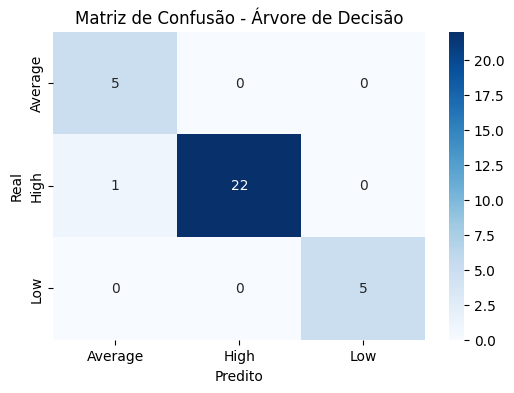


Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.83      1.00      0.91         5
        High       1.00      0.96      0.98        23
         Low       1.00      1.00      1.00         5

    accuracy                           0.97        33
   macro avg       0.94      0.99      0.96        33
weighted avg       0.97      0.97      0.97        33



In [13]:
# Previsões nos dados de teste
y_pred_test = modelo_gini.predict(X_test)

# Acurácia no teste
acc_test = accuracy_score(y_test, y_pred_test)

print("Acurácia nos dados de treino:", acc_train)
print("Acurácia nos dados de teste:", acc_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)

print("\nMatriz de Confusão:")
print(cm)

# Plotar matriz de confusão
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_gini.classes_,
            yticklabels=modelo_gini.classes_)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_test))

O modelo de árvore de decisão apresentou **acurácia igual a 1.0 nos dados de treino**, indicando que o modelo conseguiu classificar corretamente todas as observações utilizadas no treinamento.

Já nos dados de** teste, a acurácia foi de aproximadamente 0.97**, demonstrando que o modelo manteve um desempenho elevado ao ser aplicado a dados não vistos anteriormente. A pequena diferença entre as acurácias de treino e teste sugere **a presença de um leve overfitting**, o que é comum em árvores de decisão sem restrições, porém não compromete significativamente a capacidade de generalização do modelo.

A matriz de confusão mostra que houve apenas um erro de classificação, onde um registro da classe High foi classificado como Average, enquanto as demais classes foram corretamente previstas. O relatório de classificação indica valores elevados de recall e F1-score para todas as classes, especialmente para as classes High e Low, que apresentaram valores próximos ou iguais a 1.00. A classe Average apresentou desempenho ligeiramente inferior em precisão, mas ainda dentro de um nível satisfatório. **De forma geral, o modelo demonstrou excelente desempenho tanto na base de treino quanto na base de teste, indicando boa capacidade preditiva e estabilidade nos resultados**.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

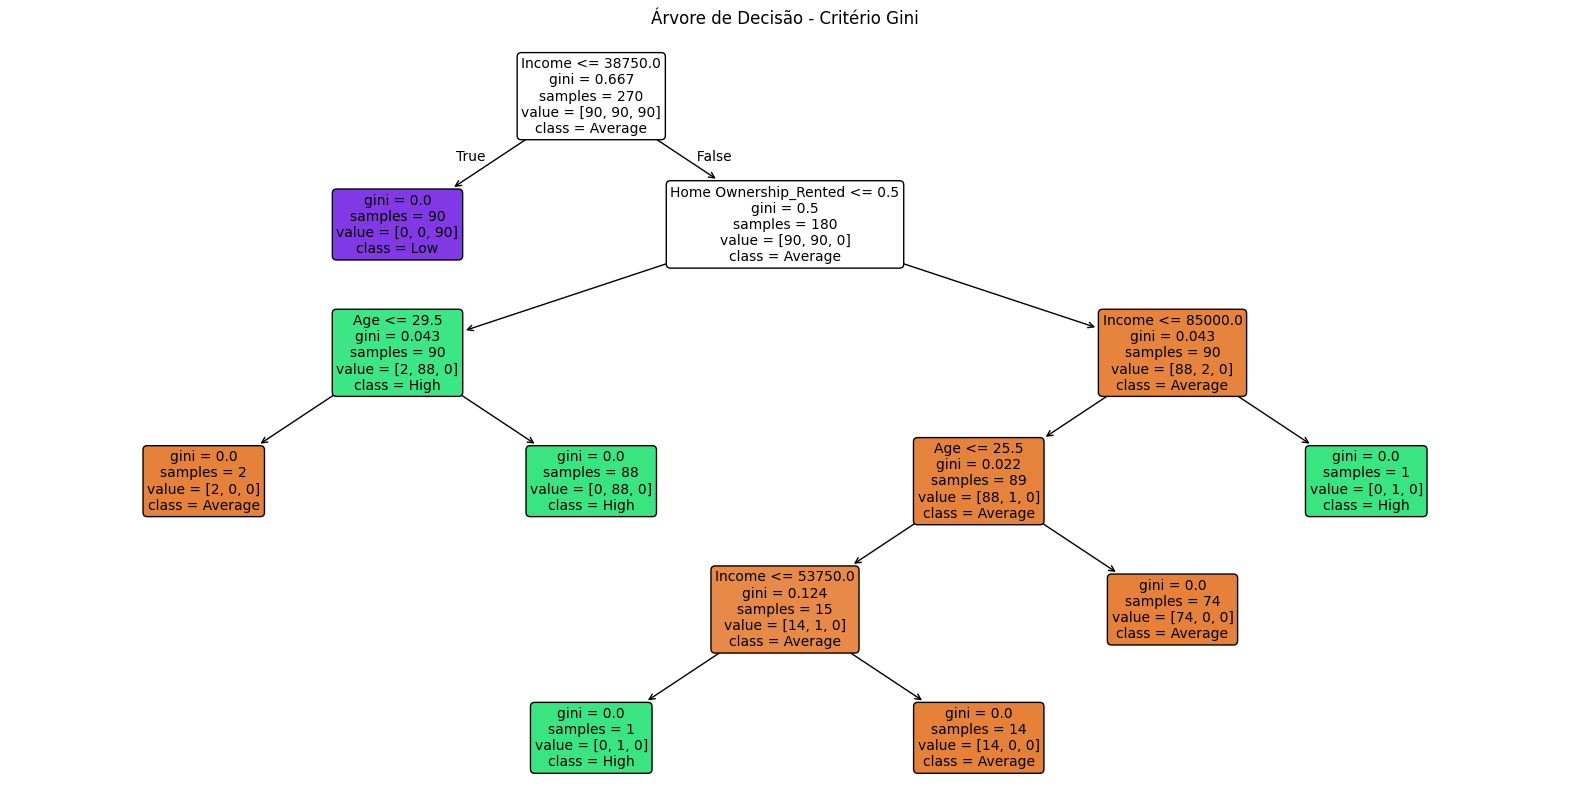

In [14]:
plt.figure(figsize=(20,10))

plot_tree(
    modelo_gini,
    feature_names=X_train.columns,
    class_names=modelo_gini.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão - Critério Gini")
plt.show()

Sim, é possível realizar uma avaliação visual da árvore de decisão observando as variáveis utilizadas nos primeiros nós, a profundidade da árvore e a pureza dos nós finais (folhas).

- Visualmente, observa-se que a variável Income aparece como o primeiro critério de divisão da árvore, indicando que ela é a variável mais importante para a separação inicial das classes de Credit Score. Quando o valor de Income é menor ou igual a 38750, a árvore classifica diretamente a maioria dos registros como Low, demonstrando uma separação clara dessa classe.

- Nos níveis seguintes, observa-se a presença da variável Home Ownership_Rented, indicando que o tipo de moradia também possui influência na classificação do score de crédito. Além disso, a variável Age aparece em divisões posteriores, indicando que a idade também contribui para refinar a separação entre as classes Average e High.

- Outro aspecto visual importante é que muitos nós finais apresentam gini igual a 0.0, indicando que esses nós são puros, ou seja, contêm registros de apenas uma única classe. Isso sugere que o modelo conseguiu separar bem os dados durante o treinamento.

# 6) Identifique as 2 principais features do modelo.


In [15]:
# Criar DataFrame com importância das variáveis
importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': modelo_gini.feature_importances_
})

# Ordenar da maior para a menor importância
importancias = importancias.sort_values(by='Importancia', ascending=False)

# Mostrar todas (opcional)
print(importancias)

# Mostrar as 2 principais features
top2 = importancias.head(2)

print("\nAs 2 principais features do modelo são:")
print(top2)

                         Feature  Importancia
1                         Income     0.521112
9          Home Ownership_Rented     0.456543
0                            Age     0.022344
2             Number of Children     0.000000
4    Education_Bachelor's Degree     0.000000
3                    Gender_Male     0.000000
5            Education_Doctorate     0.000000
6  Education_High School Diploma     0.000000
7      Education_Master's Degree     0.000000
8          Marital Status_Single     0.000000

As 2 principais features do modelo são:
                 Feature  Importancia
1                 Income     0.521112
9  Home Ownership_Rented     0.456543


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

Acurácia treino (Top 2 features): 0.9962962962962963
Acurácia teste (Top 2 features): 0.9393939393939394

Matriz de Confusão:
[[ 4  1  0]
 [ 1 22  0]
 [ 0  0  5]]


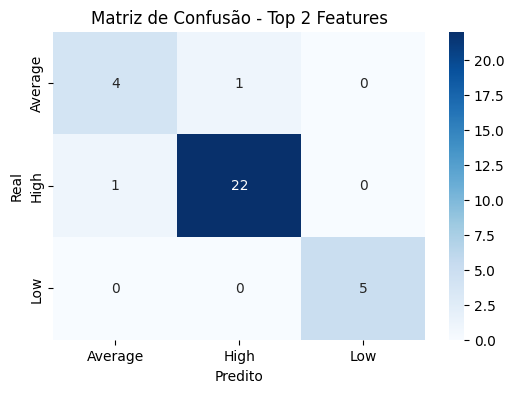


Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.80      0.80      0.80         5
        High       0.96      0.96      0.96        23
         Low       1.00      1.00      1.00         5

    accuracy                           0.94        33
   macro avg       0.92      0.92      0.92        33
weighted avg       0.94      0.94      0.94        33



In [16]:
# Selecionar apenas as 2 principais features
features_top2 = ['Income', 'Home Ownership_Rented']

X_train_top2 = X_train[features_top2]
X_test_top2 = X_test[features_top2]

# Criar novo modelo
modelo_top2 = DecisionTreeClassifier(
    criterion='gini',
    random_state=0
)

# Treinar modelo
modelo_top2.fit(X_train_top2, y_train)

# Previsões treino
y_pred_train_top2 = modelo_top2.predict(X_train_top2)

# Previsões teste
y_pred_test_top2 = modelo_top2.predict(X_test_top2)

# Acurácia treino
acc_train_top2 = accuracy_score(y_train, y_pred_train_top2)

# Acurácia teste
acc_test_top2 = accuracy_score(y_test, y_pred_test_top2)

print("Acurácia treino (Top 2 features):", acc_train_top2)
print("Acurácia teste (Top 2 features):", acc_test_top2)

# Matriz de confusão
cm_top2 = confusion_matrix(y_test, y_pred_test_top2)

print("\nMatriz de Confusão:")
print(cm_top2)

# Plotar matriz
plt.figure(figsize=(6,4))
sns.heatmap(cm_top2, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_top2.classes_,
            yticklabels=modelo_top2.classes_)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Top 2 Features")
plt.show()

# Relatório
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_test_top2))

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

Ao comparar os resultados obtidos com os modelos de Árvore de Decisão e Naive Bayes, observa-se que ambos apresentaram bom desempenho na classificação do Credit Score. O modelo Naive Bayes apresentou acurácia de 1.0 nos dados de teste, indicando que todos os registros foram corretamente classificados, sem erros observados na matriz de confusão.

Por outro lado, o modelo de Árvore de Decisão também apresentou desempenho elevado, com acurácia de 1.0 nos dados de treino e aproximadamente 0.97 nos dados de teste, indicando que houve apenas um pequeno erro de classificação. As métricas de recall e F1-score também apresentaram valores altos para todas as classes, demonstrando boa capacidade de classificação.

Comparando os dois modelos, o Naive Bayes parece ter se adequado melhor aos dados, pois apresentou desempenho perfeito nos dados de teste, sem erros de classificação. Além disso, o fato de manter acurácia máxima indica que o modelo conseguiu generalizar bem os padrões presentes nos dados.

Entretanto,** o modelo de Árvore de Decisão também demonstrou excelente desempenho e possui a vantagem de ser mais interpretável, permitindo visualizar claramente as regras de decisão e identificar as variáveis mais importantes, como Income e Home Ownership_Rented, que tiveram maior influência nas classificações**.

**De forma geral, embora ambos os modelos tenham apresentado resultados satisfatórios**, o **Naive Bayes apresentou desempenho ligeiramente superior** nos dados avaliados, sendo o modelo que melhor se ajustou aos dados neste caso específico.